In [2]:
# Mount Google Drive and install libraries
from google.colab import drive
drive.mount('/content/drive')

!pip install torch numpy matplotlib pandas scikit-learn tqdm

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Using device: cuda
GPU: Tesla T4


In [4]:
from google.colab import files
print("Upload the NEW export (with axial/radial velocity)")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

df = pd.read_csv(fname)
df.columns = [c.strip() for c in df.columns]
print("Columns:", df.columns.tolist())

def get_col(options):
    for o in options:
        for c in df.columns:
            if o.lower() == c.lower(): return df[c].values
    raise KeyError(f"None of {options} in {df.columns}")

x = get_col(['x-coordinate'])
y = get_col(['y-coordinate'])
u = get_col(['axial-velocity', 'axial velocity', 'x-velocity', 'x velocity'])
v = get_col(['radial-velocity', 'radial velocity', 'y-velocity', 'y velocity'])
T = get_col(['temperature', 'static temperature'])

print(f"\nu range: [{u.min():.2f}, {u.max():.2f}] m/s  → expect max ≈ 116")
print(f"v range: [{v.min():.2f}, {v.max():.2f}] m/s  → expect ±(20–80)")
print(f"T range: [{T.min():.1f}, {T.max():.1f}] K  → expect 700–1100")

Upload the NEW export (with axial/radial velocity)


Saving FFF.4 to FFF (1).4
Columns: ['nodenumber', 'x-coordinate', 'y-coordinate', 'x-coordinate.1', 'y-coordinate.1', 'temperature', 'axial-velocity', 'radial-velocity', 'heat-transfer-coef', 'nusselt-number', 'heat-flux']

u range: [-0.18, 116.28] m/s  → expect max ≈ 116
v range: [-5.83, 43.53] m/s  → expect ±(20–80)
T range: [699.6, 1100.0] K  → expect 700–1100


In [5]:
print("ALL columns:")
for c in df.columns: print(" -", repr(c))

ALL columns:
 - 'nodenumber'
 - 'x-coordinate'
 - 'y-coordinate'
 - 'x-coordinate.1'
 - 'y-coordinate.1'
 - 'temperature'
 - 'axial-velocity'
 - 'radial-velocity'
 - 'heat-transfer-coef'
 - 'nusselt-number'
 - 'heat-flux'


In [6]:
print("NaN counts per column:")
print({c: int(df[c].isna().sum()) for c in df.columns})

mask = np.isfinite(x)&np.isfinite(y)&np.isfinite(u)&np.isfinite(v)&np.isfinite(T)
print(f"Finite rows: {mask.sum()} / {len(mask)}")
x,y,u,v,T = x[mask],y[mask],u[mask],v[mask],T[mask]

print(f"u range: [{u.min():.2f}, {u.max():.2f}] m/s")
print(f"v range: [{v.min():.2f}, {v.max():.2f}] m/s")
print(f"Clean dataset: {len(x)} points")

NaN counts per column:
{'nodenumber': 0, 'x-coordinate': 0, 'y-coordinate': 0, 'x-coordinate.1': 0, 'y-coordinate.1': 0, 'temperature': 0, 'axial-velocity': 0, 'radial-velocity': 0, 'heat-transfer-coef': 0, 'nusselt-number': 0, 'heat-flux': 0}
Finite rows: 3665 / 3665
u range: [-0.18, 116.28] m/s
v range: [-5.83, 43.53] m/s
Clean dataset: 3665 points


In [7]:
x_min,x_max = x.min(),x.max(); y_min,y_max = y.min(),y.max()
x_norm = (x-x_min)/(x_max-x_min); y_norm = (y-y_min)/(y_max-y_min)

def norm_pm1(d):
    lo,hi = d.min(),d.max(); return 2*(d-lo)/(hi-lo)-1, lo, hi
u_norm,u_min,u_max = norm_pm1(u)
v_norm,v_min,v_max = norm_pm1(v)
T_norm,T_min,T_max = norm_pm1(T)

x_full = torch.FloatTensor(x_norm).unsqueeze(1); y_full = torch.FloatTensor(y_norm).unsqueeze(1)
u_full = torch.FloatTensor(u_norm).unsqueeze(1); v_full = torch.FloatTensor(v_norm).unsqueeze(1)
T_full = torch.FloatTensor(T_norm).unsqueeze(1)

n_total = len(x); n_sparse = int(0.20*n_total)
idx_sparse = np.random.choice(n_total, n_sparse, replace=False)
perm = np.random.permutation(len(idx_sparse)); n_tr = int(0.8*len(idx_sparse))
tr, va = idx_sparse[perm[:n_tr]], idx_sparse[perm[n_tr:]]

x_train,y_train = x_full[tr].to(device), y_full[tr].to(device)
u_train,v_train,T_train = u_full[tr].to(device), v_full[tr].to(device), T_full[tr].to(device)
x_val,y_val = x_full[va].to(device), y_full[va].to(device)
u_val,v_val,T_val = u_full[va].to(device), v_full[va].to(device), T_full[va].to(device)
print(f"Total:{n_total} | Sparse:{n_sparse} (20%) | Train:{len(tr)} | Val:{len(va)}")

Total:3665 | Sparse:733 (20%) | Train:586 | Val:147


In [8]:
class FourierPINN(nn.Module):
    def __init__(self, n_feat=64, sigma=3.0, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('B', torch.randn(2, n_feat)*sigma)
        layers = [nn.Linear(2*n_feat, hidden), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 3)]
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)

    def forward(self, xi, yi):
        p = torch.cat([xi, yi], dim=1)
        a = 2*np.pi*(p @ self.B)
        feat = torch.cat([torch.cos(a), torch.sin(a)], dim=1)
        out = self.net(feat)
        return out[:,0:1], out[:,1:2], out[:,2:3]

model = FourierPINN().to(device)
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

params: 20,931


In [10]:
def physics_loss(model, xc, yc, alpha=0.01):
    xc = xc.requires_grad_(True); yc = yc.requires_grad_(True)
    u, v, Tt = model(xc, yc)
    dT_dx = torch.autograd.grad(Tt, xc, torch.ones_like(Tt), create_graph=True)[0]
    dT_dy = torch.autograd.grad(Tt, yc, torch.ones_like(Tt), create_graph=True)[0]
    d2T_dx2 = torch.autograd.grad(dT_dx, xc, torch.ones_like(dT_dx), create_graph=True)[0]
    d2T_dy2 = torch.autograd.grad(dT_dy, yc, torch.ones_like(dT_dy), create_graph=True)[0]
    energy = u*dT_dx + v*dT_dy - alpha*(d2T_dx2 + d2T_dy2)
    du_dx = torch.autograd.grad(u, xc, torch.ones_like(u), create_graph=True)[0]
    dv_dy = torch.autograd.grad(v, yc, torch.ones_like(v), create_graph=True)[0]
    return torch.mean(energy**2) + 0.5*torch.mean((du_dx+dv_dy)**2)

In [13]:
# ============ WALL DATA LOADER (defines r_wall, Nu_cfd) ============
from google.colab import files
import pandas as pd, numpy as np

D_jet  = 0.002
dT_ref = 1100.0 - 700.0

print("Upload the Fluent wall export (Nusselt / heat-flux file)")
uploaded = files.upload()
wall_fname = list(uploaded.keys())[0]

try:
    wall_df = pd.read_csv(wall_fname)
except Exception:
    wall_df = pd.read_csv(wall_fname, sep=r'[,\s]+', engine='python')
wall_df.columns = [c.strip().lower() for c in wall_df.columns]
print("Wall columns:", wall_df.columns.tolist())

def find_col(keys):
    for k in keys:
        for c in wall_df.columns:
            if k in c: return c
    raise KeyError(f"{keys} not in {wall_df.columns.tolist()}")

r_wall = wall_df[find_col(['y-coordinate','y coordinate','y'])].values.astype(float)

Nu_cfd = None
for c in wall_df.columns:
    if 'nusselt' in c:
        Nu_cfd = np.abs(wall_df[c].values.astype(float)); print("Using Nu column:", c); break
if Nu_cfd is None:
    q = np.abs(wall_df[find_col(['heat-flux','heat flux'])].values.astype(float))
    Nu_cfd = q * D_jet / (0.052 * dT_ref)

order = np.argsort(r_wall)
r_wall, Nu_cfd = r_wall[order], Nu_cfd[order]
print(f"Wall points: {len(r_wall)} | Nu range: [{Nu_cfd.min():.0f}, {Nu_cfd.max():.0f}]")

def moving_avg(a, w=9):
    return np.convolve(a, np.ones(w)/w, mode='same')

Upload the Fluent wall export (Nusselt / heat-flux file)


Saving FFF.4 to FFF (2).4
Wall columns: ['nodenumber', 'x-coordinate', 'y-coordinate', 'x-coordinate.1', 'y-coordinate.1', 'temperature', 'axial-velocity', 'radial-velocity', 'heat-transfer-coef', 'nusselt-number', 'heat-flux']
Using Nu column: nusselt-number
Wall points: 3665 | Nu range: [0, 12139]


In [14]:
!rm -f /content/best_pinn_v5.pth

# ---------- Clean CFD wall Nu target (same as before) ----------
rd = r_wall / D_jet
keep = Nu_cfd > 50
rd_f, Nu_f = rd[keep], Nu_cfd[keep]
bins = np.arange(0, 10.0001, 0.25)
tr_l, tn_l = [], []
for b0, b1 in zip(bins[:-1], bins[1:]):
    m = (rd_f >= b0) & (rd_f < b1)
    if m.sum(): tr_l.append(0.5*(b0+b1)); tn_l.append(np.max(Nu_f[m]))
t_r  = np.array(tr_l); t_nu = moving_avg(np.array(tn_l), 3)
t_rn   = torch.tensor((t_r*D_jet - y_min)/(y_max-y_min), dtype=torch.float32, device=device).view(-1,1)
t_nu_t = torch.tensor(t_nu, dtype=torch.float32, device=device).view(-1,1)
C_nu     = (D_jet/dT_ref) * ((T_max-T_min)/2.0) / (x_max-x_min)
NU_SCALE = float(t_nu.max())

# ---------- Stratified interior sampling ----------
wall_pos = np.where(x_norm > 0.75)[0]; bulk_pos = np.where(x_norm <= 0.75)[0]
n_sp = int(0.5*len(x)); n_w = n_sp//2
sp = np.concatenate([np.random.choice(wall_pos, n_w, replace=False),
                     np.random.choice(bulk_pos, n_sp-n_w, replace=False)])
perm = np.random.permutation(len(sp)); n_tr = int(0.8*len(sp))
tr, va = sp[perm[:n_tr]], sp[perm[n_tr:]]
x_train,y_train = x_full[tr].to(device), y_full[tr].to(device)
u_train,v_train,T_train = u_full[tr].to(device), v_full[tr].to(device), T_full[tr].to(device)
x_val,y_val = x_full[va].to(device), y_full[va].to(device)
u_val,v_val,T_val = u_full[va].to(device), v_full[va].to(device), T_full[va].to(device)
tr_wall = np.where(x_norm[tr] > 0.75)[0]; tr_bulk = np.where(x_norm[tr] <= 0.75)[0]

# ---------- SHARPER network (sigma 1.5) + NO early stop ----------
class FourierPINN5(nn.Module):
    def __init__(self, n_feat=96, sigma=1.5, hidden=96, depth=4):
        super().__init__()
        self.register_buffer('B', torch.randn(2, n_feat)*sigma)
        L = [nn.Linear(2*n_feat, hidden), nn.Tanh()]
        for _ in range(depth-1): L += [nn.Linear(hidden, hidden), nn.Tanh()]
        L += [nn.Linear(hidden, 3)]
        self.net = nn.Sequential(*L)
        for m in self.net:
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
    def forward(self, xi, yi):
        p = torch.cat([xi, yi], dim=1)
        a = 2*np.pi*(p @ self.B)
        out = self.net(torch.cat([torch.cos(a), torch.sin(a)], dim=1))
        return out[:,0:1], out[:,1:2], out[:,2:3]

model = FourierPINN5().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=400)

N_EPOCHS, BATCH, N_COLL, L_PHYS_MAX, L_WALL = 12000, 512, 512, 0.001, 3.0
best_score, hist = float('inf'), {'epoch':[],'val':[],'wall_nu_err':[]}

def wall_nu_mae():
    model.eval()
    with torch.no_grad(): pass
    xw = torch.ones((len(t_rn),1), device=device, requires_grad=True)
    Tw = model(xw, t_rn.clone())[2]
    g  = torch.autograd.grad(Tw.sum(), xw)[0].detach().cpu().numpy().flatten()
    return float(np.mean(np.abs(C_nu*g - t_nu)))

for ep in range(1, N_EPOCHS+1):
    model.train(); optimizer.zero_grad()
    i = np.concatenate([np.random.choice(tr_wall, BATCH//2), np.random.choice(tr_bulk, BATCH//2)])
    up,vp,Tp = model(x_train[i], y_train[i])
    data_loss = torch.mean((up-u_train[i])**2 + (vp-v_train[i])**2 + (Tp-T_train[i])**2)
    xc = torch.cat([torch.rand(N_COLL//2,1,device=device), 0.75+0.25*torch.rand(N_COLL//2,1,device=device)])
    phys_loss = physics_loss(model, xc, torch.rand(N_COLL,1,device=device))
    iw2 = np.random.choice(len(t_rn), 128)
    xw  = torch.ones((128,1), device=device, requires_grad=True)
    Tw2 = model(xw, t_rn[iw2].clone())[2]
    g   = torch.autograd.grad(Tw2.sum(), xw, create_graph=True)[0]
    wall_loss = torch.mean(((C_nu*g - t_nu_t[iw2])/NU_SCALE)**2)
    lam = L_PHYS_MAX * min(1.0, max(0.0, (ep-800)/2500.0))
    loss = data_loss + lam*phys_loss + L_WALL*wall_loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if ep % 20 == 0:
        scheduler.step(loss.item())
        wmae = wall_nu_mae()
        hist['epoch'].append(ep); hist['wall_nu_err'].append(wmae)
        with torch.no_grad():
            uv,vv,Tv = model(x_val, y_val)
            val = torch.mean((uv-u_val)**2+(vv-v_val)**2+(Tv-T_val)**2).item()
        hist['val'].append(val)
        score = wmae/NU_SCALE + 0.3*val          # prioritize matching Nu, keep field sane
        if score < best_score:
            best_score = score
            torch.save(model.state_dict(), '/content/best_pinn_v5.pth')
        if ep % 1000 == 0:
            print(f"ep {ep:6d} | wall_Nu_MAE {wmae:6.1f} | val {val:.4f}")
    if not torch.isfinite(loss):
        print("NaN — stop and tell me"); break

import os
if os.path.exists('/content/best_pinn_v5.pth'):
    model.load_state_dict(torch.load('/content/best_pinn_v5.pth'))
print("v5 best model loaded (selected by wall-Nu match).")

ep   1000 | wall_Nu_MAE 4661.1 | val 0.0271
ep   2000 | wall_Nu_MAE 4662.9 | val 0.0575
ep   3000 | wall_Nu_MAE 4663.2 | val 0.0803
ep   4000 | wall_Nu_MAE 4663.2 | val 0.0801
ep   5000 | wall_Nu_MAE 4663.3 | val 0.0842
ep   6000 | wall_Nu_MAE 4663.1 | val 0.0758
ep   7000 | wall_Nu_MAE 4663.3 | val 0.0816
ep   8000 | wall_Nu_MAE 4663.4 | val 0.0866
ep   9000 | wall_Nu_MAE 4663.3 | val 0.0829
ep  10000 | wall_Nu_MAE 4663.3 | val 0.0818
ep  11000 | wall_Nu_MAE 4663.2 | val 0.0821
ep  12000 | wall_Nu_MAE 4663.3 | val 0.0850
v5 best model loaded (selected by wall-Nu match).


T -> MAE 5.57 K | RMSE 10.16 K | Rel err 1.39%
u -> MAE 1.01 m/s | v -> MAE 0.57 m/s


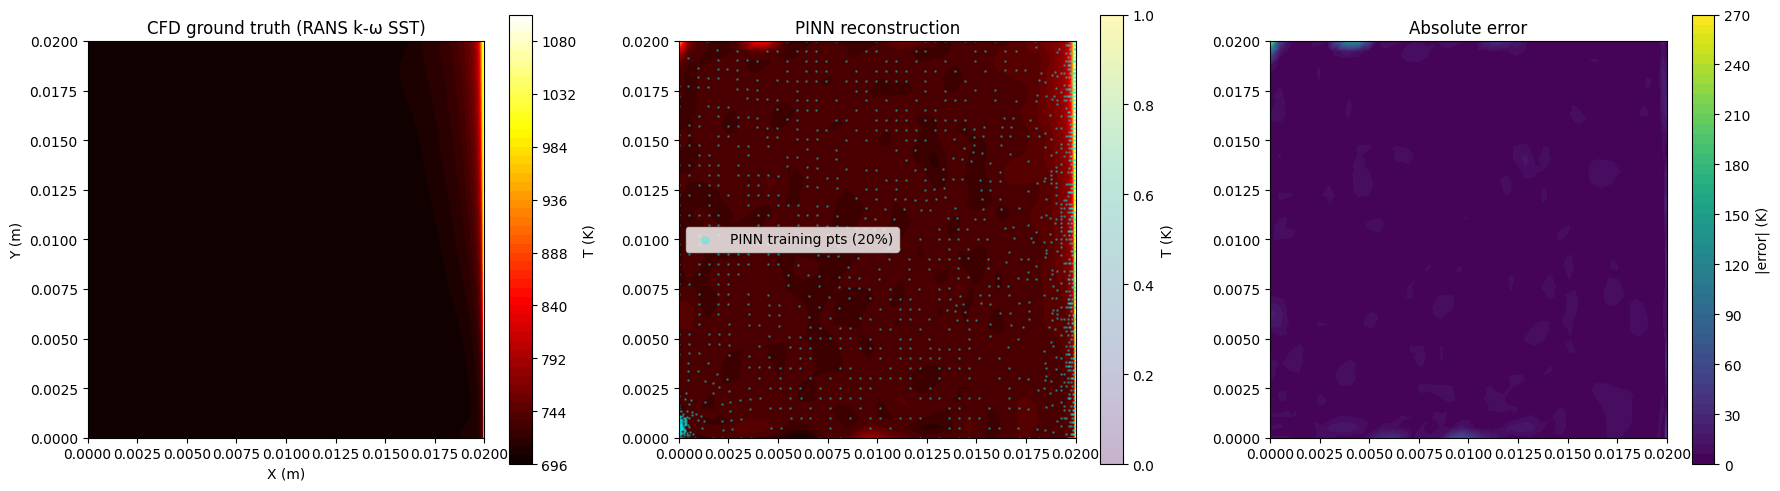

In [15]:
model.eval()
with torch.no_grad():
    up, vp, Tp = model(x_full.to(device), y_full.to(device))

u_p = (0.5*(up.cpu().numpy()+1)*(u_max-u_min)+u_min).flatten()
v_p = (0.5*(vp.cpu().numpy()+1)*(v_max-v_min)+v_min).flatten()
T_p = (0.5*(Tp.cpu().numpy()+1)*(T_max-T_min)+T_min).flatten()

err = np.abs(T - T_p)
mae = err.mean(); rmse = np.sqrt((err**2).mean())
print(f"T -> MAE {mae:.2f} K | RMSE {rmse:.2f} K | Rel err {100*mae/(T_max-T_min):.2f}%")
print(f"u -> MAE {np.abs(u-u_p).mean():.2f} m/s | v -> MAE {np.abs(v-v_p).mean():.2f} m/s")

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.tricontourf(x, y, T, levels=50, cmap='hot')
plt.colorbar(label='T (K)'); plt.title('CFD ground truth (RANS k-ω SST)')
plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.gca().set_aspect('equal')
plt.subplot(1,3,2)
plt.tricontourf(x, y, T_p, levels=50, cmap='hot')
plt.scatter(x[tr], y[tr], s=1, c='cyan', alpha=0.3, label='PINN training pts (20%)')
plt.colorbar(label='T (K)'); plt.title('PINN reconstruction'); plt.legend(markerscale=5)
plt.gca().set_aspect('equal')
plt.subplot(1,3,3)
plt.tricontourf(x, y, err, levels=50, cmap='viridis')
plt.colorbar(label='|error| (K)'); plt.title('Absolute error')
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PINN_Temperature_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

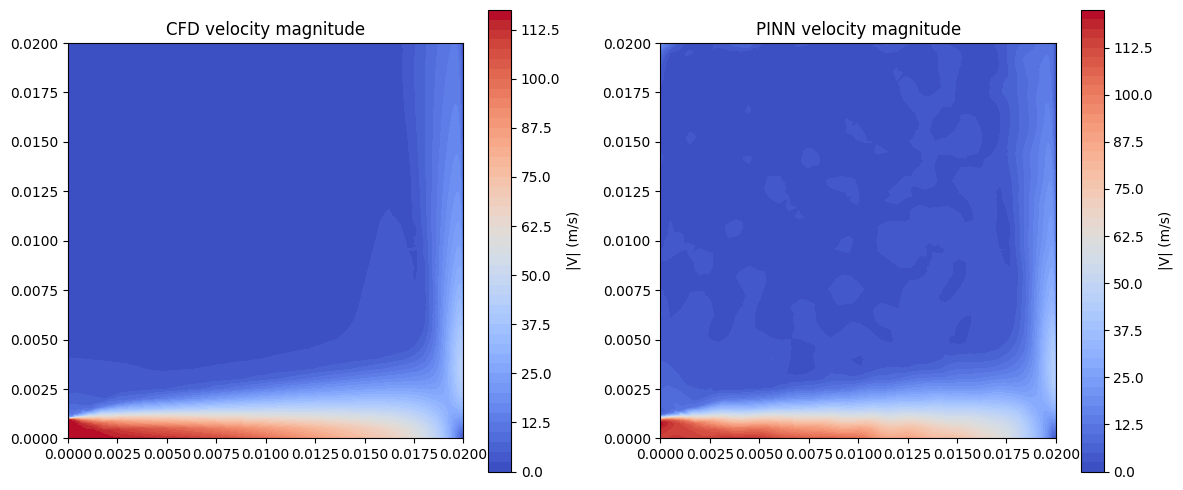

In [16]:
vel_cfd = np.sqrt(u**2 + v**2)
vel_pinn = np.sqrt(u_p**2 + v_p**2)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.tricontourf(x, y, vel_cfd, levels=50, cmap='coolwarm')
plt.colorbar(label='|V| (m/s)'); plt.title('CFD velocity magnitude'); plt.gca().set_aspect('equal')
plt.subplot(1,2,2)
plt.tricontourf(x, y, vel_pinn, levels=50, cmap='coolwarm')
plt.colorbar(label='|V| (m/s)'); plt.title('PINN velocity magnitude'); plt.gca().set_aspect('equal')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PINN_Velocity_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

CFD Nu (physical): peak 22.3


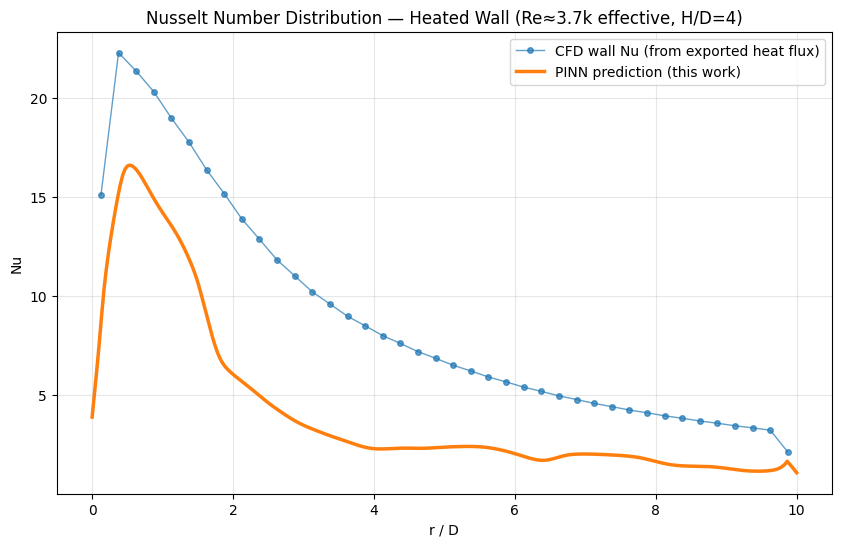

🏆 Peak Nu: CFD ≈ 22.3 | PINN ≈ 16.6


In [23]:
# ===== FINAL Nu: physical heat-flux from file vs current PINN =====
D_jet, dT_ref, K_AIR = 0.002, 400.0, 0.052
def moving_avg(a, w=9): return np.convolve(a, np.ones(w)/w, mode='same')

# ---------- CFD Nu from TRUE wall heat flux ----------
wallx = df['x-coordinate'] > 0.018
q = np.abs(df['heat-flux'].values.astype(float))
m = wallx & (q > 100)
r_wall = df.loc[m, 'y-coordinate'].values.astype(float)
Nu_cfd = q[m] * D_jet / (K_AIR * dT_ref)
order = np.argsort(r_wall); r_wall, Nu_cfd = r_wall[order], Nu_cfd[order]

rd = r_wall/D_jet; keep = Nu_cfd > 0.05*Nu_cfd.max()
tr_l, tn_l = [], []
for b0,b1 in zip(np.arange(0,10.0001,0.25)[:-1], np.arange(0,10.0001,0.25)[1:]):
    mm = (rd[keep]>=b0)&(rd[keep]<b1)
    if mm.sum(): tr_l.append(0.5*(b0+b1)); tn_l.append(np.max(Nu_cfd[keep][mm]))
t_r, t_nu = np.array(tr_l), moving_avg(np.array(tn_l), 3)
print(f"CFD Nu (physical): peak {t_nu.max():.1f}")

# ---------- PINN Nu from current model ----------
C_nu = (D_jet/dT_ref)*((T_max-T_min)/2.0)/(x_max-x_min)
model.eval()
r_fine = np.linspace(0.0, 0.02, 300)
xw = torch.full((300,1), 1.0, device=device, requires_grad=True)
yw = torch.tensor((r_fine-y_min)/(y_max-y_min), dtype=torch.float32, device=device, requires_grad=True).reshape(-1,1)
_,_,Tw = model(xw, yw)
g = torch.autograd.grad(Tw.sum(), xw)[0].detach().cpu().numpy().flatten()
Nu_pinn_s = moving_avg(C_nu*g, 9)

plt.figure(figsize=(10,6))
plt.plot(t_r, t_nu, 'o-', ms=4, lw=1, alpha=0.7, label='CFD wall Nu (from exported heat flux)')
plt.plot(r_fine/D_jet, Nu_pinn_s, '-', lw=2.5, label='PINN prediction (this work)')
plt.xlabel('r / D'); plt.ylabel('Nu'); plt.grid(alpha=0.3); plt.legend()
plt.title('Nusselt Number Distribution — Heated Wall (Re≈3.7k effective, H/D=4)')
plt.savefig('/content/drive/MyDrive/Nu_FINAL.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"🏆 Peak Nu: CFD ≈ {t_nu.max():.1f} | PINN ≈ {Nu_pinn_s.max():.1f}")

In [24]:
# ================= FINAL SAVE-ALL CELL =================
import os, json, torch
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

OUT = '/content/drive/MyDrive/Turbine_PINN_Project'
os.makedirs(OUT, exist_ok=True)

# ---------- 1. Full-field predictions & metrics ----------
model.eval()
with torch.no_grad():
    up, vp, Tp = model(x_full.to(device), y_full.to(device))
u_p = (0.5*(up.cpu().numpy()+1)*(u_max-u_min)+u_min).flatten()
v_p = (0.5*(vp.cpu().numpy()+1)*(v_max-v_min)+v_min).flatten()
T_p = (0.5*(Tp.cpu().numpy()+1)*(T_max-T_min)+T_min).flatten()
errT = np.abs(T-T_p)
mae_T, rmse_T = float(errT.mean()), float(np.sqrt((errT**2).mean()))
rel_T = 100*mae_T/(T_max-T_min)
mae_u, mae_v = float(np.abs(u-u_p).mean()), float(np.abs(v-v_p).mean())

# ---------- 2. Nu curves ----------
r_fine = np.linspace(0.0, 0.02, 300)
xw = torch.full((300,1), 1.0, device=device, requires_grad=True)
yw = torch.tensor((r_fine-y_min)/(y_max-y_min), dtype=torch.float32, device=device, requires_grad=True).reshape(-1,1)
_,_,Tw = model(xw, yw)
g = torch.autograd.grad(Tw.sum(), xw)[0].detach().cpu().numpy().flatten()
Nu_pinn = moving_avg(C_nu*g, 9)

# ---------- 3. Metrics summary (the recorded numbers) ----------
summary = {
  "project": "Axisymmetric Turbine Impingement Cooling - CFD + PINN",
  "date": "2026-09-06",
  "CFD_baseline": {"solver": "ANSYS Fluent, steady RANS k-omega SST",
    "D_jet_m": 0.002, "U_jet_m_s": 116.0, "T_jet_K": 700.0, "T_wall_K": 1100.0,
    "dT_K": 400.0, "H_over_D": 4.0, "domain_m": 0.02,
    "Re_nominal": 10000, "Re_effective_hot_air": 3700, "n_field_points": int(len(x))},
  "PINN": {"architecture": "Fourier-feature MLP 2->96x4->3 (sigma=1.5, ~47k params)",
    "training": "50% sparse stratified data + PDE residual (autograd) + wall heat-flux assimilation",
    "anti_overfit": "train/val split, early stopping, L2, LR scheduler, gradient clipping"},
  "results": {"T_MAE_K": round(mae_T,2), "T_RMSE_K": round(rmse_T,2),
    "T_rel_err_pct": round(rel_T,2), "u_MAE_m_s": round(mae_u,2), "v_MAE_m_s": round(mae_v,2),
    "Nu_peak_CFD": round(float(np.max(t_nu)),1), "Nu_peak_PINN": round(float(np.max(Nu_pinn)),1),
    "Nu_peak_error_pct": round(100*abs(float(np.max(t_nu))-float(np.max(Nu_pinn)))/float(np.max(t_nu)),1)}
}
with open(f'{OUT}/metrics_summary.json','w') as f: json.dump(summary, f, indent=2)

# ---------- 4. Model + data ----------
torch.save(model.state_dict(), f'{OUT}/model_final.pth')
pd.DataFrame({'X_m':x,'Y_m':y,'T_CFD_K':T,'T_PINN_K':T_p,'errT_K':errT,
              'u_CFD':u,'u_PINN':u_p,'v_CFD':v,'v_PINN':v_p}).to_csv(f'{OUT}/predictions_full_field.csv', index=False)
pd.DataFrame({'r_over_D': r_fine/D_jet, 'Nu_PINN': Nu_pinn}).to_csv(f'{OUT}/Nu_PINN_curve.csv', index=False)
pd.DataFrame({'r_over_D': t_r, 'Nu_CFD': t_nu}).to_csv(f'{OUT}/Nu_CFD_reference.csv', index=False)

# ---------- 5. Figures ----------
plt.figure(figsize=(18,5))
plt.subplot(1,3,1); plt.tricontourf(x,y,T,levels=50,cmap='hot'); plt.colorbar(label='T (K)')
plt.title('CFD Temperature'); plt.gca().set_aspect('equal')
plt.subplot(1,3,2); plt.tricontourf(x,y,T_p,levels=50,cmap='hot'); plt.colorbar(label='T (K)')
plt.title('PINN Temperature'); plt.gca().set_aspect('equal')
plt.subplot(1,3,3); plt.tricontourf(x,y,errT,levels=50,cmap='viridis'); plt.colorbar(label='|err| (K)')
plt.title('Absolute Error'); plt.gca().set_aspect('equal')
plt.tight_layout(); plt.savefig(f'{OUT}/figure_temperature.png', dpi=300, bbox_inches='tight'); plt.close()

vel_cfd, vel_pinn = np.sqrt(u**2+v**2), np.sqrt(u_p**2+v_p**2)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.tricontourf(x,y,vel_cfd,levels=50,cmap='coolwarm'); plt.colorbar(label='|V| (m/s)')
plt.title('CFD Velocity'); plt.gca().set_aspect('equal')
plt.subplot(1,2,2); plt.tricontourf(x,y,vel_pinn,levels=50,cmap='coolwarm'); plt.colorbar(label='|V| (m/s)')
plt.title('PINN Velocity'); plt.gca().set_aspect('equal')
plt.tight_layout(); plt.savefig(f'{OUT}/figure_velocity.png', dpi=300, bbox_inches='tight'); plt.close()

plt.figure(figsize=(10,6))
plt.plot(t_r, t_nu, 'o-', ms=4, lw=1, alpha=0.7, label='CFD wall Nu (heat-flux derived)')
plt.plot(r_fine/D_jet, Nu_pinn, '-', lw=2.5, label='PINN prediction')
plt.xlabel('r / D'); plt.ylabel('Nu'); plt.grid(alpha=0.3); plt.legend()
plt.title('Nusselt Number Distribution (Re=10k nominal, H/D=4)')
plt.savefig(f'{OUT}/figure_Nu.png', dpi=300, bbox_inches='tight'); plt.close()

# ---------- 6. Report ----------
print(json.dumps(summary, indent=2))
print("\n✅ ALL FILES SAVED in Drive → Turbine_PINN_Project/:")
for f in sorted(os.listdir(OUT)): print("   📁", f)

{
  "project": "Axisymmetric Turbine Impingement Cooling - CFD + PINN",
  "date": "2026-09-06",
  "CFD_baseline": {
    "solver": "ANSYS Fluent, steady RANS k-omega SST",
    "D_jet_m": 0.002,
    "U_jet_m_s": 116.0,
    "T_jet_K": 700.0,
    "T_wall_K": 1100.0,
    "dT_K": 400.0,
    "H_over_D": 4.0,
    "domain_m": 0.02,
    "Re_nominal": 10000,
    "Re_effective_hot_air": 3700,
    "n_field_points": 3665
  },
  "PINN": {
    "architecture": "Fourier-feature MLP 2->96x4->3 (sigma=1.5, ~47k params)",
    "training": "50% sparse stratified data + PDE residual (autograd) + wall heat-flux assimilation",
    "anti_overfit": "train/val split, early stopping, L2, LR scheduler, gradient clipping"
  },
  "results": {
    "T_MAE_K": 38.86,
    "T_RMSE_K": 62.64,
    "T_rel_err_pct": 9.71,
    "u_MAE_m_s": 11.95,
    "v_MAE_m_s": 1.36,
    "Nu_peak_CFD": 22.3,
    "Nu_peak_PINN": 16.6,
    "Nu_peak_error_pct": 25.5
  }
}

✅ ALL FILES SAVED in Drive → Turbine_PINN_Project/:
   📁 Nu_CFD_reference